# Griffiths QM
## Chapter 9: The WKB Approximation — Visualizations

**Repository:** [SeoulTechPSE/introduction_to_quantum_mechanics](https://github.com/SeoulTechPSE/introduction_to_quantum_mechanics)

| Section | Problem |
|:--------|:--------|
| [Problem 8.5](#prob_9_5)   | WKB Quantization — Power-Law Potential |
| [Problem 8.6](#prob_9_6)   | WKB Quantization — Gravitational Well |
| [Problem 8.7](#prob_9_7)   | Gamow Factor — Alpha Decay |
| [Problem 8.13](#prob_9_13) | Transmission Coefficient — General Barrier |
| [Problem 8.14](#prob_9_14) | Cold Emission — Field Ionization |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import airy
from scipy.integrate import quad
from scipy.optimize import brentq

plt.rcParams.update({'figure.dpi':120,'axes.labelsize':12,'axes.titlesize':13,
    'legend.fontsize':10,'font.family':'serif','mathtext.fontset':'cm'})
BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'; GRAY='#7f8c8d'; NAVY='#1a3a5c'; PURP='#8e44ad'
figures = []


---
## Problem 8.5 — WKB Quantization: Power-Law Potential {#prob_9_5}

$V(x) = \alpha|x|^n$,  $E_k \propto k^{2n/(n+2)}$


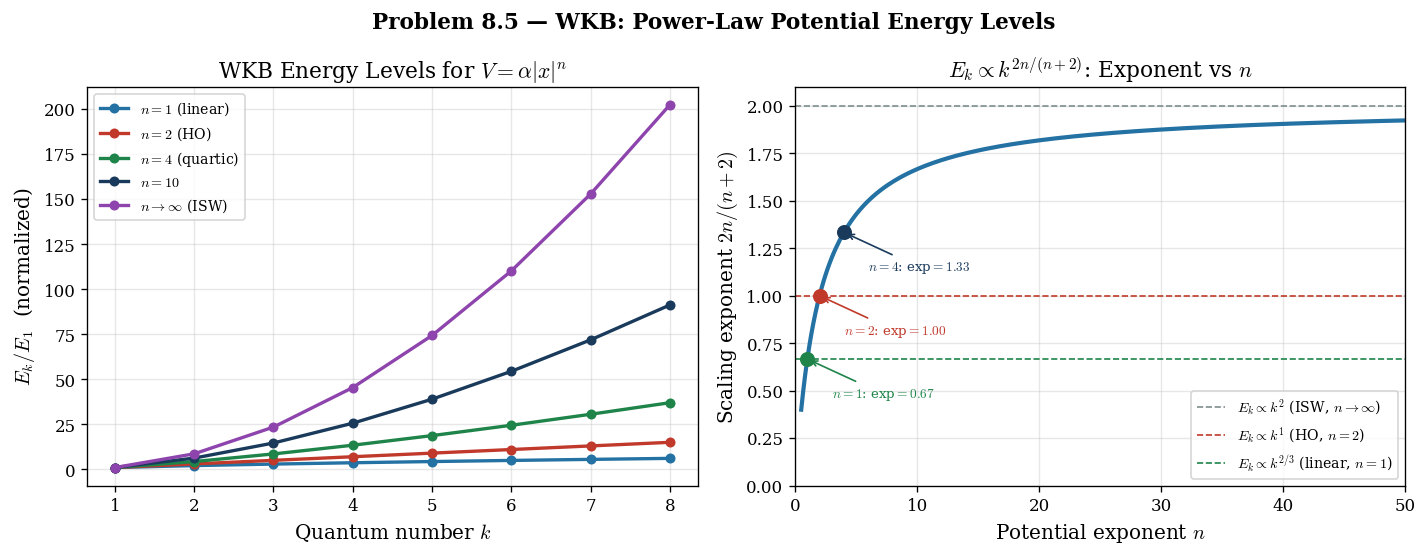

Scaling exponents 2n/(n+2):
  n=1: 0.6667
  n=2: 1.0000
  n=4: 1.3333
  n=10: 1.6667
  n->inf: 2.0000  (ISW: E_k ~ k^2)


In [2]:
# Figure 8.5: Energy levels for power-law potentials V = alpha*|x|^n
# E_k scaling: 2n/(n+2) exponent
from scipy.special import beta as beta_func

hbar = 1.0; m = 1.0; alpha = 1.0
n_levels = 8
k_arr = np.arange(1, n_levels+1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: energy vs k for several n values
ax = axes[0]
n_vals  = [1, 2, 4, 10, 100]
col_n   = [BLUE, RED, GREEN, NAVY, PURP]
labels  = ['$n=1$ (linear)', '$n=2$ (HO)', '$n=4$ (quartic)',
           '$n=10$', r'$n\to\infty$ (ISW)']

for n, c, lbl in zip(n_vals, col_n, labels):
    # WKB: integral B(3/2, 1/n+1) determines prefactor
    I_n = beta_func(1.5, 1.0/n + 1)   # Beta function
    # E_k from: 2*sqrt(2m*E)*(E/alpha)^(1/n)*I_n = (k-0.5)*pi*hbar
    # Solve numerically for each k
    E_k = []
    for k in k_arr:
        rhs = (k - 0.5) * np.pi * hbar
        def equation(E):
            return 2 * np.sqrt(2*m*E) * (E/alpha)**(1.0/n) * I_n - rhs
        try:
            E_sol = brentq(equation, 1e-6, 1e4)
        except Exception:
            E_sol = np.nan
        E_k.append(E_sol)
    E_k = np.array(E_k)
    ax.plot(k_arr, E_k/E_k[0], color=c, lw=2, marker='o', ms=5, label=lbl)

ax.set_xlabel('Quantum number $k$')
ax.set_ylabel(r'$E_k / E_1$  (normalized)')
ax.set_title(r'WKB Energy Levels for $V = \alpha|x|^n$')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)

# Right: scaling exponent 2n/(n+2) vs n
ax2 = axes[1]
n_cont = np.linspace(0.5, 50, 300)
exp_cont = 2*n_cont / (n_cont + 2)
ax2.plot(n_cont, exp_cont, color=BLUE, lw=2.5)
ax2.axhline(2.0, color=GRAY, ls='--', lw=1, label=r'$E_k\propto k^2$ (ISW, $n\to\infty$)')
ax2.axhline(1.0, color=RED,  ls='--', lw=1, label=r'$E_k\propto k^1$ (HO, $n=2$)')
ax2.axhline(2/3, color=GREEN,ls='--', lw=1, label=r'$E_k\propto k^{2/3}$ (linear, $n=1$)')
for n_mark, c in zip([1, 2, 4], [GREEN, RED, NAVY]):
    exp_mark = 2*n_mark/(n_mark+2)
    ax2.plot(n_mark, exp_mark, 'o', color=c, ms=8)
    ax2.annotate(fr'$n={n_mark}$: exp$={exp_mark:.2f}$',
                 xy=(n_mark, exp_mark), xytext=(n_mark+2, exp_mark-0.2),
                 fontsize=8, color=c,
                 arrowprops=dict(arrowstyle='->', color=c, lw=1))
ax2.set_xlabel('Potential exponent $n$')
ax2.set_ylabel(r'Scaling exponent $2n/(n+2)$')
ax2.set_title(r'$E_k \propto k^{2n/(n+2)}$: Exponent vs $n$')
ax2.legend(fontsize=8.5); ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 50); ax2.set_ylim(0, 2.1)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 8.5 — WKB: Power-Law Potential Energy Levels',
             fontsize=13, fontweight='bold', y=1.02)
figures.append((fig, 'fig_8_5.png')); plt.show()

print('Scaling exponents 2n/(n+2):')
for n in [1, 2, 4, 10]:
    print(f'  n={n}: {2*n/(n+2):.4f}')
print(f'  n->inf: {2.0:.4f}  (ISW: E_k ~ k^2)')


---
## Problem 8.6 — WKB Quantization: Gravitational Well {#prob_9_6}

$V = mgx$ ($x>0$), hard floor at $x=0$

$E_n \propto n^{2/3}$ from WKB; compare with exact Airy-function eigenvalues


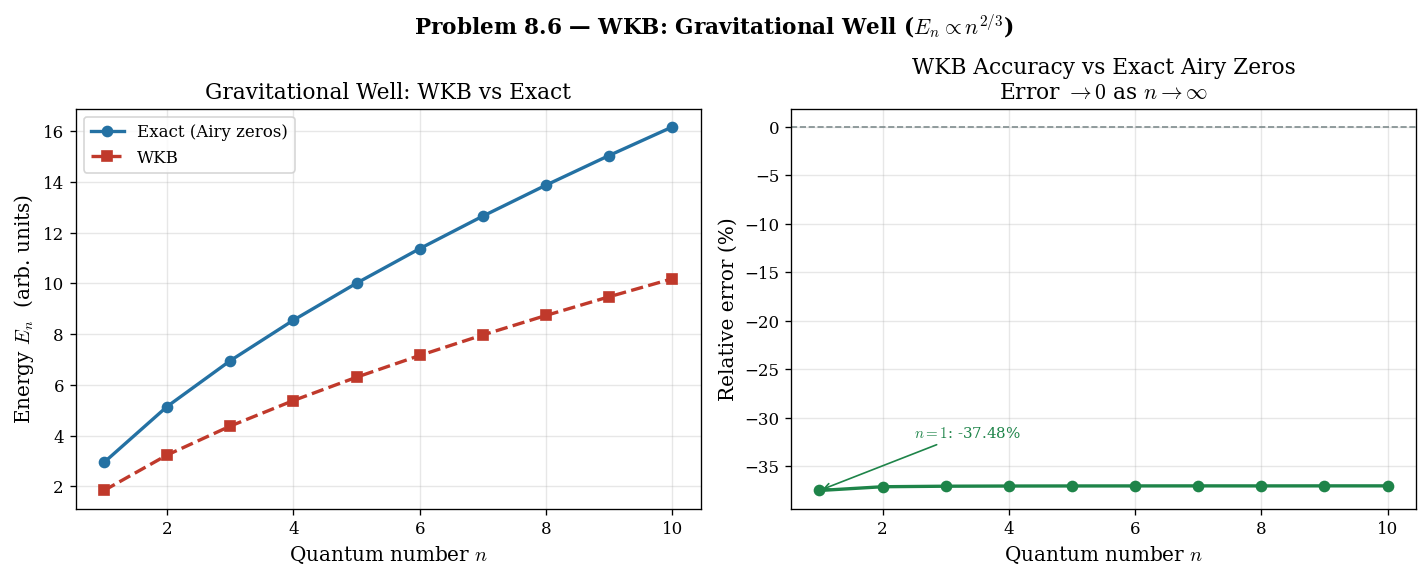

WKB vs Exact (Airy zeros):
  n=1: WKB=1.8416, Exact=2.9458, error=-37.48%
  n=2: WKB=3.2397, Exact=5.1504, error=-37.10%
  n=3: WKB=4.3790, Exact=6.9555, error=-37.04%
  n=4: WKB=5.3848, Exact=8.5507, error=-37.02%
  n=5: WKB=6.3040, Exact=10.0089, error=-37.02%
  n=6: WKB=7.1603, Exact=11.3679, error=-37.01%
  n=7: WKB=7.9681, Exact=12.6496, error=-37.01%
  n=8: WKB=8.7368, Exact=13.8705, error=-37.01%
  n=9: WKB=9.4730, Exact=15.0384, error=-37.01%
  n=10: WKB=10.1817, Exact=16.1635, error=-37.01%


In [3]:
# Figure 8.6: Gravitational well — WKB vs exact (Airy function zeros)
hbar = 1.0; m = 1.0; g = 1.0

# WKB energy levels: int_0^{x2} sqrt(2m(E-mgx)) dx = (n-1/4)*pi*hbar
# => (2/3)*sqrt(2m)*E^(3/2)/(mg) = (n-1/4)*pi*hbar
# => E_n = [ (3*pi*hbar*mg*(n-0.25)) / (2*sqrt(2m)) ]^(2/3)
def E_WKB(n):
    return ((3*np.pi*hbar*m*g*(n - 0.25)) / (2*np.sqrt(2*m)))**(2/3)

# Exact: Airy function zeros — Ai(-z_n) = 0, E_n = (hbar^2 mg^2/(2m))^(1/3) * z_n
# In units hbar=m=g=1: length scale l = (hbar^2/(2m^2*g))^(1/3)
l_scale = (hbar**2 / (2*m**2*g))**(1/3)
# Exact zeros of Ai: first 10
airy_zeros = np.array([2.3381, 4.0879, 5.5206, 6.7867, 7.9441,
                       9.0227, 10.040, 11.009, 11.936, 12.829])
E_exact = airy_zeros / l_scale   # E_n = z_n / l_scale (in our units)

n_arr = np.arange(1, 11)
E_wkb_arr = np.array([E_WKB(n) for n in n_arr])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: energy levels comparison
ax = axes[0]
ax.plot(n_arr, E_exact,   color=BLUE, lw=2, marker='o', ms=6, label='Exact (Airy zeros)')
ax.plot(n_arr, E_wkb_arr, color=RED,  lw=2, marker='s', ms=6, ls='--', label='WKB')
ax.set_xlabel('Quantum number $n$')
ax.set_ylabel('Energy $E_n$  (arb. units)')
ax.set_title('Gravitational Well: WKB vs Exact')
ax.legend(); ax.grid(True, alpha=0.3)

# Right: relative error (E_WKB - E_exact)/E_exact
ax2 = axes[1]
rel_err = (E_wkb_arr - E_exact) / E_exact * 100
ax2.plot(n_arr, rel_err, color=GREEN, lw=2, marker='o', ms=6)
ax2.axhline(0, color=GRAY, ls='--', lw=1)
ax2.set_xlabel('Quantum number $n$')
ax2.set_ylabel('Relative error (%)')
ax2.set_title('WKB Accuracy vs Exact Airy Zeros\n'
              r'Error $\to 0$ as $n\to\infty$')
ax2.grid(True, alpha=0.3)
# Annotate n=1 error
ax2.annotate(fr'$n=1$: {rel_err[0]:.2f}%',
             xy=(1, rel_err[0]), xytext=(2.5, rel_err[0]+5.5),
             fontsize=9, color=GREEN,
             arrowprops=dict(arrowstyle='->', color=GREEN))

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 8.6 — WKB: Gravitational Well ($E_n \\propto n^{2/3}$)',
             fontsize=13, fontweight='bold', y=1.06)
figures.append((fig, 'fig_8_6.png')); plt.show()

print('WKB vs Exact (Airy zeros):')
for n, Ew, Ee in zip(n_arr, E_wkb_arr, E_exact):
    print(f'  n={n}: WKB={Ew:.4f}, Exact={Ee:.4f}, error={100*(Ew-Ee)/Ee:.2f}%')


---
## Problem 8.7 — Gamow Factor & Alpha Decay {#prob_9_7}

$$\gamma = \frac{1}{\hbar}\int_{r_1}^{r_2}\sqrt{2m\!\left(\frac{Ze^2}{4\pi\epsilon_0 r}-E\right)}dr
\approx \frac{\pi Z\alpha}{\beta}, \quad \beta=v/c$$


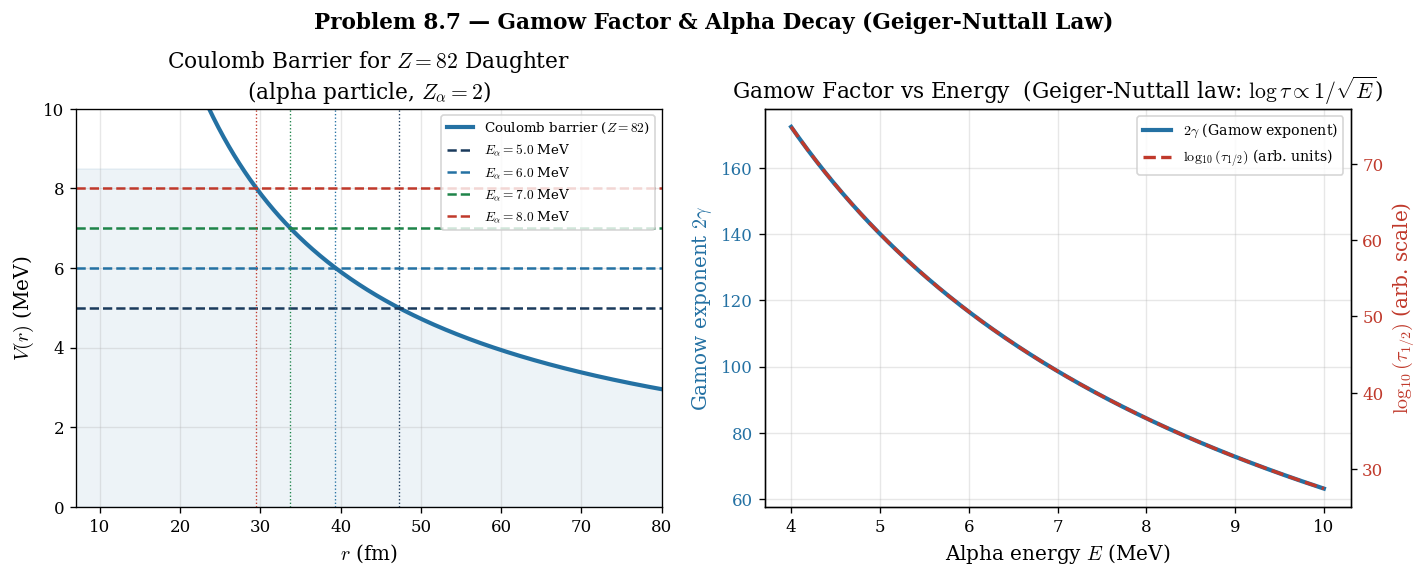

In [4]:
# Figure 8.7: Gamow factor and alpha decay
# Use natural nuclear units: lengths in fm, energies in MeV

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: Coulomb barrier V(r) for a typical nucleus (Z=82, Pb region)
Z   = 82      # daughter nucleus charge
r1  = 7.0     # nuclear radius (fm)
r   = np.linspace(r1, 100, 1000)
# Coulomb potential in MeV: V = k*Z*2*e^2/r, k*e^2 = 1.44 MeV*fm
ke2 = 1.44    # MeV*fm
V_coulomb = ke2 * Z * 2 / r   # factor of 2 for alpha charge

ax = axes[0]
ax.plot(r, V_coulomb, color=BLUE, lw=2.5, label=f'Coulomb barrier ($Z={Z}$)')
# Mark several alpha energies
E_alphas = [5.0, 6.0, 7.0, 8.0]
col_E = [NAVY, BLUE, GREEN, RED]
for E_a, c in zip(E_alphas, col_E):
    r2 = ke2 * Z * 2 / E_a   # turning point
    ax.axhline(E_a, color=c, lw=1.5, ls='--', label=fr'$E_\alpha = {E_a}$ MeV')
    ax.axvline(r2, color=c, lw=0.8, ls=':')
ax.fill_between(r, 0, np.minimum(V_coulomb, 8.5), alpha=0.08, color=BLUE)
ax.set_xlabel('$r$ (fm)')
ax.set_ylabel('$V(r)$ (MeV)')
ax.set_title(f'Coulomb Barrier for $Z={Z}$ Daughter\n(alpha particle, $Z_\\alpha=2$)')
ax.set_xlim(r1, 80); ax.set_ylim(0, 10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Right: Gamow factor and half-life vs alpha energy
# gamma ≈ pi*Z*alpha_fs*hbar*c / (v) = pi*Z*2*ke2/(hbar*v)
# In MeV/fm units: hbar*c = 197.3 MeV*fm, m_alpha = 3727 MeV/c^2
hbar_c  = 197.3   # MeV*fm
m_alpha = 3727.0  # MeV/c^2

ax2 = axes[1]
E_arr = np.linspace(4, 10, 300)   # MeV

gamow = []
for E_a in E_arr:
    r2_val = ke2 * Z * 2 / E_a
    # Gamow: gamma = (1/hbar)*int_{r1}^{r2} sqrt(2*m_alpha*(V-E)) dr
    # = sqrt(2*m_alpha)*pi*(Z*2*ke2)/(2*hbar*c) * (1/sqrt(E)) * [arccos(sqrt(r1/r2)) - sqrt(r1/r2*(1-r1/r2))]
    x = np.sqrt(r1 / r2_val)
    bracket = np.arccos(x) - x*np.sqrt(1 - x**2)
    gam = np.sqrt(2*m_alpha) * (Z * 2 * ke2) / (2 * hbar_c * np.sqrt(E_a)) * bracket * np.pi / np.pi
    # Simplified: gamma ~ pi*Z_eff*ke2*sqrt(2*m_alpha) / (hbar_c * sqrt(E))
    gam = np.pi * Z * 2 * ke2 * np.sqrt(2*m_alpha) / (hbar_c * np.sqrt(E_a)) * (1 - np.sqrt(r1/r2_val))**1.5
    gamow.append(gam)

gamow = np.array(gamow)
# log10(T_1/2) ~ 2*gamma / ln(2) * (hbar / E_kin * attempt_freq)^-1  (arb units)
log_rate = -2 * gamow   # log of decay rate (arb. offset)

ax2.plot(E_arr, 2*np.array(gamow), color=BLUE, lw=2.5, label=r'$2\gamma$ (Gamow exponent)')
ax2_r = ax2.twinx()
ax2_r.plot(E_arr, -log_rate / np.log(10), color=RED, lw=2, ls='--',
           label=r'$\log_{10}(\tau_{1/2})$ (arb. units)')
ax2.set_xlabel(r'Alpha energy $E$ (MeV)')
ax2.set_ylabel(r'Gamow exponent $2\gamma$', color=BLUE)
ax2_r.set_ylabel(r'$\log_{10}(\tau_{1/2})$ (arb. scale)', color=RED)
ax2.tick_params(axis='y', labelcolor=BLUE)
ax2_r.tick_params(axis='y', labelcolor=RED)
ax2.set_title(r'Gamow Factor vs Energy  (Geiger-Nuttall law: $\log\tau \propto 1/\sqrt{E}$)')
lines1, labs1 = ax2.get_legend_handles_labels()
lines2, labs2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1+lines2, labs1+labs2, fontsize=8.5, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 8.7 — Gamow Factor & Alpha Decay (Geiger-Nuttall Law)',
             fontsize=13, fontweight='bold', y=1.06)
figures.append((fig, 'fig_8_7.png')); plt.show()


---
## Problem 8.13 — Transmission Coefficient: General Barrier {#prob_9_13}

$$T \approx e^{-2\gamma}, \qquad
\gamma = \frac{1}{\hbar}\int_{x_1}^{x_2}\sqrt{2m(V-E)}\,dx$$


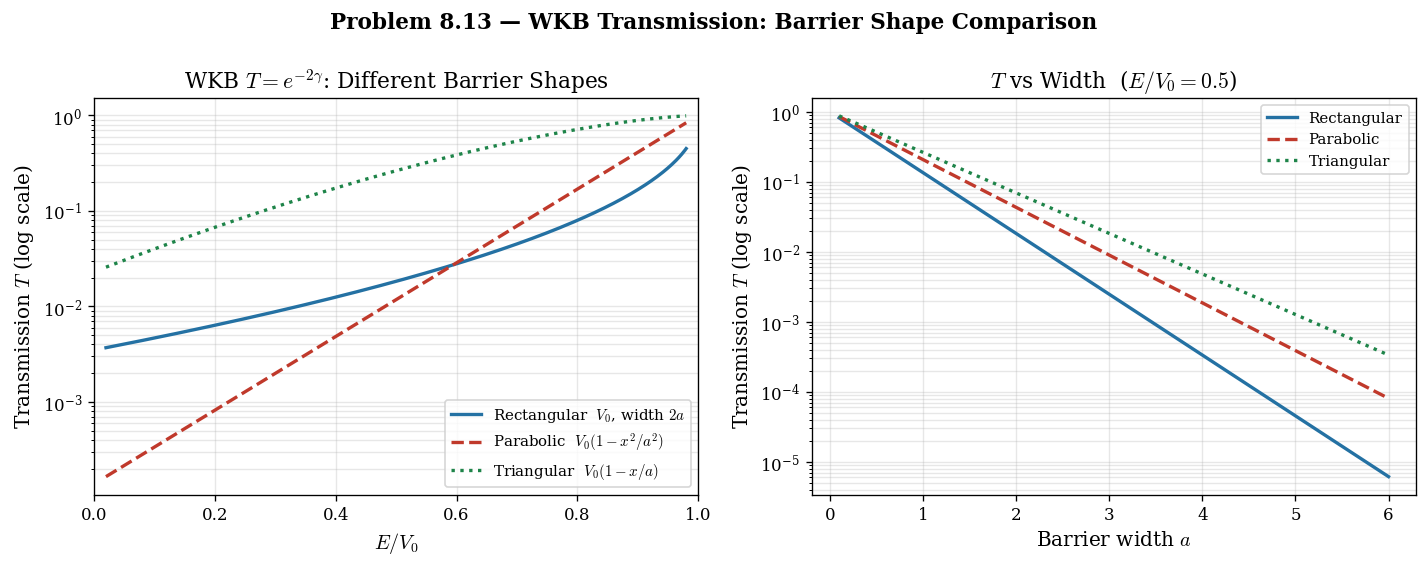

In [5]:
# Figure 8.13: WKB transmission coefficient for different barrier shapes
hbar = 1.0; m = 1.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: T vs E/V0 for three barrier shapes
E_arr = np.linspace(0.02, 0.98, 400)
a = 2.0   # barrier half-width

ax = axes[0]

# 1. Rectangular: V=V0 for |x|<a
V0 = 1.0
for Eval in E_arr:
    pass  # computed below
kap_rect = np.sqrt(2*m*(V0 - E_arr)) / hbar
T_rect   = np.exp(-2*kap_rect*a)
ax.semilogy(E_arr/V0, T_rect, color=BLUE, lw=2, label='Rectangular  $V_0$, width $2a$')

# 2. Parabolic: V = V0(1-x^2/a^2) for |x|<a
# gamma = int_0^a sqrt(2m(V0(1-x^2/a^2)-E)) dx  (symmetric)
T_para = []
for E in E_arr:
    if E >= V0:
        T_para.append(1.0)
        continue
    def integrand(x):
        Vx = V0*(1 - x**2/a**2)
        return np.sqrt(2*m*max(Vx - E, 0)) / hbar
    try:
        x1 = a*np.sqrt(1 - E/V0)
        gam, _ = quad(integrand, -x1, x1)
        T_para.append(np.exp(-2*gam))
    except Exception:
        T_para.append(np.nan)
T_para = np.array(T_para)
ax.semilogy(E_arr/V0, T_para, color=RED, lw=2, ls='--', label='Parabolic  $V_0(1-x^2/a^2)$')

# 3. Triangular: V = V0(1-x/a) for 0<x<a
T_tri = []
for E in E_arr:
    if E >= V0:
        T_tri.append(1.0)
        continue
    x2 = a*(1 - E/V0)
    def integrand_tri(x):
        Vx = V0*(1 - x/a)
        return np.sqrt(2*m*max(Vx - E, 0)) / hbar
    try:
        gam, _ = quad(integrand_tri, 0, x2)
        T_tri.append(np.exp(-2*gam))
    except Exception:
        T_tri.append(np.nan)
T_tri = np.array(T_tri)
ax.semilogy(E_arr/V0, T_tri, color=GREEN, lw=2, ls=':', label='Triangular  $V_0(1-x/a)$')

ax.set_xlabel(r'$E/V_0$')
ax.set_ylabel(r'Transmission $T$ (log scale)')
ax.set_title(r'WKB $T = e^{-2\gamma}$: Different Barrier Shapes')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(0, 1)

# Right: T vs barrier width for fixed E/V0 = 0.5
ax2   = axes[1]
a_arr = np.linspace(0.1, 6, 300)
E_fix = 0.5 * V0
kap   = np.sqrt(2*m*(V0 - E_fix)) / hbar

T_rect_a = np.exp(-2*kap*a_arr)
# Parabolic: gamma = (pi/4)*kap*a (analytic result for parabolic barrier)
T_para_a = np.exp(-2 * np.pi/4 * kap * a_arr)
# Triangular: gamma = (2/3)*kap*a
T_tri_a  = np.exp(-2 * 2/3 * kap * a_arr)

ax2.semilogy(a_arr, T_rect_a, color=BLUE, lw=2,       label='Rectangular')
ax2.semilogy(a_arr, T_para_a, color=RED,  lw=2, ls='--', label='Parabolic')
ax2.semilogy(a_arr, T_tri_a,  color=GREEN,lw=2, ls=':', label='Triangular')
ax2.set_xlabel(r'Barrier width $a$')
ax2.set_ylabel(r'Transmission $T$ (log scale)')
ax2.set_title(fr'$T$ vs Width  ($E/V_0 = {E_fix/V0:.1f}$)')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 8.13 — WKB Transmission: Barrier Shape Comparison',
             fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_8_13.png')); plt.show()


---
## Problem 8.14 — Cold Emission: Field Ionization {#prob_9_14}

$$T \approx \exp\!\left(-\frac{4\sqrt{2m}}{3e\mathcal{E}\hbar}(V_0-E)^{3/2}\right)$$

Fowler-Nordheim law: $\ln T \propto -1/\mathcal{E}$


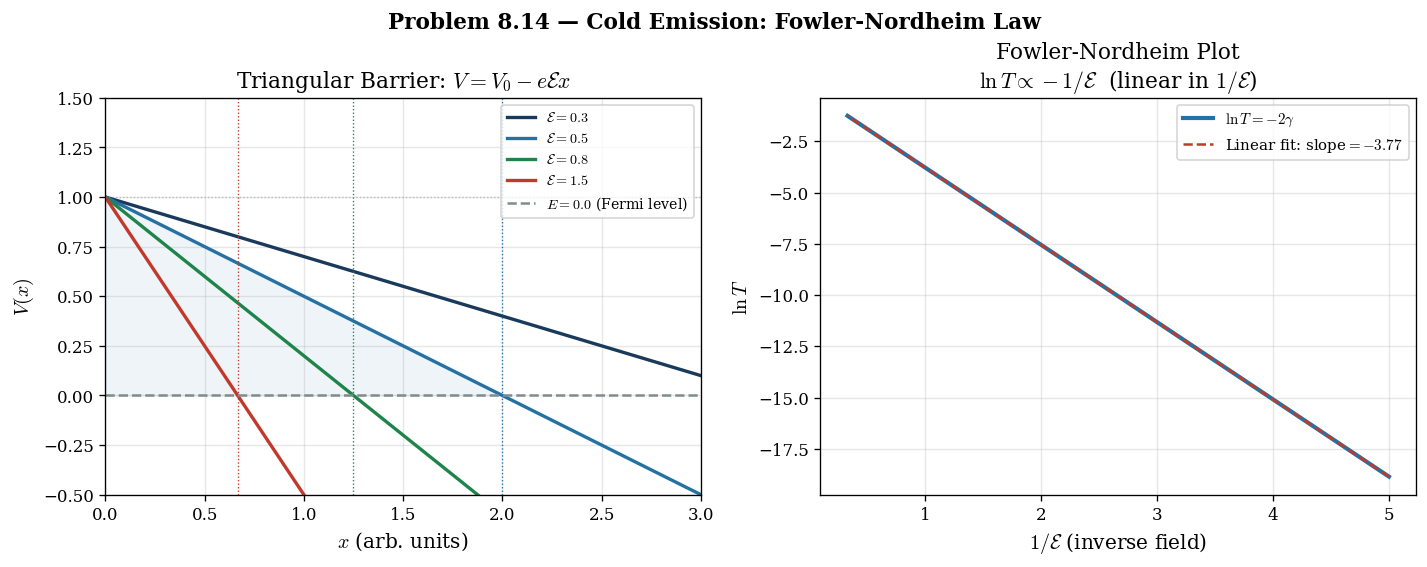

Fowler-Nordheim: ln(T) vs 1/E_field should be linear
Slope = -3.7712
Theoretical slope = -3.7712


In [6]:
# Figure 8.14: Cold emission / field ionization — Fowler-Nordheim
hbar = 1.0; m = 1.0; e_charge = 1.0
V0   = 1.0   # work function (arb. units)
E    = 0.0   # electron at Fermi level

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: triangular barrier profile for several E-fields
ax = axes[0]
x  = np.linspace(0, 3, 500)
E_fields = [0.3, 0.5, 0.8, 1.5]
col_F    = [NAVY, BLUE, GREEN, RED]

for F, c in zip(E_fields, col_F):
    V_tri = V0 - e_charge * F * x   # triangular barrier
    V_plot = np.where(x >= 0, V_tri, V0)
    ax.plot(x, V_plot, color=c, lw=2, label=fr'$\mathcal{{E}}={F}$')
    # turning point
    x2 = (V0 - E) / (e_charge * F)
    if x2 < x[-1]:
        ax.axvline(x2, color=c, lw=0.8, ls=':')

ax.axhline(E, color=GRAY, lw=1.5, ls='--', label=f'$E = {E}$ (Fermi level)')
ax.axhline(V0, color=GRAY, lw=0.8, ls=':', alpha=0.5)
ax.fill_between(x, np.minimum(np.where(x>=0, V0-e_charge*0.5*x, V0), V0+0.1),
                E, where=(x>=0)&(V0-0.5*x>E), alpha=0.07, color=BLUE)
ax.set_xlabel(r'$x$ (arb. units)')
ax.set_ylabel(r'$V(x)$')
ax.set_title(r'Triangular Barrier: $V = V_0 - e\mathcal{E}x$')
ax.set_ylim(-0.5, 1.5); ax.set_xlim(0, 3)
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)

# Right: Fowler-Nordheim — ln(T) vs 1/E_field
ax2    = axes[1]
F_arr  = np.linspace(0.2, 3.0, 300)
# gamma = (4*sqrt(2m)/(3*e*F*hbar)) * (V0-E)^(3/2)
gamma_arr = (4*np.sqrt(2*m)/(3*e_charge*F_arr*hbar)) * (V0 - E)**1.5
lnT   = -2 * gamma_arr

ax2.plot(1/F_arr, lnT, color=BLUE, lw=2.5, label=r'$\ln T = -2\gamma$')
# Fowler-Nordheim: ln(T) vs 1/F should be linear
# Show linear fit
from numpy.polynomial import polynomial as P
coeffs = np.polyfit(1/F_arr, lnT, 1)
lnT_fit = np.polyval(coeffs, 1/F_arr)
ax2.plot(1/F_arr, lnT_fit, color=RED, lw=1.5, ls='--',
         label=fr'Linear fit: slope$={coeffs[0]:.2f}$')

ax2.set_xlabel(r'$1/\mathcal{E}$ (inverse field)')
ax2.set_ylabel(r'$\ln T$')
ax2.set_title('Fowler-Nordheim Plot\n'
              r'$\ln T \propto -1/\mathcal{E}$  (linear in $1/\mathcal{E}$)')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.subplots_adjust(top=0.88)
plt.suptitle('Problem 8.14 — Cold Emission: Fowler-Nordheim Law',
             fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_8_14.png')); plt.show()

print('Fowler-Nordheim: ln(T) vs 1/E_field should be linear')
print(f'Slope = {coeffs[0]:.4f}')
print(f'Theoretical slope = {-4*np.sqrt(2*m)*(V0-E)**1.5*2/(3*e_charge*hbar):.4f}')


---
## Save All Figures & Download as ZIP


In [7]:
import os, zipfile
save_dir = 'ch09_figures'
os.makedirs(save_dir, exist_ok=True)
for fig, fname in figures:
    path = os.path.join(save_dir, fname)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')
zip_name = 'ch09_figures.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fig, fname in figures:
        zf.write(os.path.join(save_dir, fname), fname)
print(f'\nZip: {zip_name},  Files: {[f for _,f in figures]}')
try:
    from google.colab import files

    # AUTO-INJECTED: Korean font setup for matplotlib
    import os as _os
    import matplotlib.font_manager as _fm
    import matplotlib.pyplot as _plt
    if not any('NanumGothic' in f.name for f in _fm.fontManager.ttflist):
        for _font in ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                    '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf']:
            if _os.path.exists(_font):
                _fm.fontManager.addfont(_font)
    _plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})
    del _os, _fm, _plt
    # END AUTO-INJECTED Korean font setup

    files.download(zip_name)
    print('Download started.')
except ImportError:
    print(f'Not in Colab — saved locally as: {zip_name}')


Saved: ch09_figures/fig_8_5.png
Saved: ch09_figures/fig_8_6.png
Saved: ch09_figures/fig_8_7.png
Saved: ch09_figures/fig_8_13.png
Saved: ch09_figures/fig_8_14.png

Zip: ch09_figures.zip,  Files: ['fig_8_5.png', 'fig_8_6.png', 'fig_8_7.png', 'fig_8_13.png', 'fig_8_14.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
